# optimize_tp_24h 程序说明

24 小时降水频率匹配订正算法（0403 号版本）。

---

## 1. 概述

`optimize_tp_24h` 针对数值模式输出的 **24 小时累积降水预报**，利用历史同期模式场与实况站点的统计关系，对当前预报进行 **空间结构订正** 与 **频率匹配订正**，生成订正后的站点（MICAPS3）和格点（MICAPS4/NC）产品。

核心思路：在历史样本中找到与当前模式场最相似的个例，借鉴其模式—实况偏差规律，结合光流位移和分位数频率匹配，改善模式降水的空间分布和量级分布。

---

## 2. 应用场景

| 场景 | 说明 |
|------|------|
| 中期降水订正 | 对 36～252 h 时效的 24 h 累积降水预报进行订正 |
| 多模式业务化 | 通过 plugin JSON 切换 ECMWF、CMA-MESO 等不同模式路径 |
| 实时/回算 | `rpt_list` 留空为实时；填写起报时间可批量回算 |
| 地方考核站部署 | 替换 `resource/sta.m3` 为地方站网模板 |

适用对象：已有模式 24 h 降水格点产品、站点 24 h 降水实况、以及足够长度历史样本的业务环境。

---

## 3. 算法原理

### 3.1 总体思路

对每个 **起报时间 + 预报时效** 组合，算法分三步：

1. **相似个例检索**：在历史模式场中，按 TS 类相似度指标找出与当前模式场空间分布最接近的样本。
2. **切片订正**（站点尺度）：将订正区域划分为若干子区域（切片），在每个切片内：
   - 用相似历史样本做 **频率匹配**，调整当前模式降水分布；
   - 时效 ≤ 60 h 时，进一步用 **光流法** 估计降水系统位移并做半拉格朗日平流订正。
3. **全域格点订正**：将各切片站点订正结果与模式背景场融合（克里金/格点插值），再对格点产品做 **频率匹配**，输出最终格点场。

### 3.2 相似度计算

模块：`src/cal_similarity.py`

- 在多个检验量级（默认 25 mm、50 mm）上，比较历史模式场与当前模式场的 TS 类得分；
- 各量级得分取平均，按得分降序排列历史样本索引；
- 累计相似度超过阈值（`sum_similar_threshold`）的样本用于后续订正。

### 3.3 光流订正

模块：`src/cal_optical_flow.py`、`src/cal_slice_tp.py`

- 取相似度最高的若干历史个例（最多 20 个）；
- 对每对历史模式—实况格点场估计光流矢量；
- 将光流叠加到当前模式场上，做半拉格朗日平流（仅 **dtime ≤ 60** 时启用）。

### 3.4 频率匹配

模块：`src/cal_frequency_match.py`

- 将模式与实况（或站点）降水按分位数等级（`fact_level` / `fact_level1`）建立映射；
- 对模式场各像素/站点做分段线性变换，使模式降水分布逼近实况分布；
- 切片阶段和最终格点阶段各执行一次频率匹配。

### 3.5 历史样本构造

- 以当前起报日期为基准，向前 **15 天**（`his_day`），并回溯 **3 年**（`his_year`）同期日历窗口；
- 逐日读取同时效的模式格点和对应时刻的站点实况；
- 模式与实况时间不一致时，按 `ipt_model` / `ipt_obs` 做 ±8 h 时区换算。

---

## 4. 算法实现流程

```
mainProcess(parafile)                         # src/correct_tp_24h.py
  └─ 按 rpt_list × [start_dtime, end_dtime] 多进程调度
       └─ correct_24H_TP(parafile, rpt, dtime)
            ├─ preLogical()          检查模式输入是否存在、输出是否覆盖
            ├─ read_his_ds()         加载历史模式格点 + 实况站点
            ├─ read_current_ds()     加载当前模式格点
            └─ mainProc()
                 ├─ cycle_correct_Slice()     逐切片：相似度 → 光流 → 频率匹配
                 ├─ _correct_current_TP_sta() 合并切片站点，写 MICAPS3
                 └─ _correct_current_TP_grd()  插值 + 频率匹配，写 MICAPS4/NC
```

### 4.1 主要源文件

| 文件 | 功能 |
|------|------|
| `src/correct_tp_24h.py` | 主流程、数据加载、切片循环、产品输出 |
| `src/cal_similarity.py` | 历史—当前模式相似度 |
| `src/cal_slice_tp.py` | 切片光流 + 频率匹配订正 |
| `src/cal_optical_flow.py` | 光流场计算 |
| `src/cal_frequency_match.py` | 频率匹配（站点/格点） |
| `src/interpolation.py` | 格点插值、平滑、区域裁剪 |
| `src/data_save.py` | MICAPS3/MICAPS4/NC 写出 |
| `src/config.py` | 算法内部参数 |
| `cli/__main__.py` | 命令行入口 |
| `utils/util_env.py` | 读取 `optimize_tp_24.ini` |

---

## 5. 关键参数说明

### 5.1 运行参数（`resource/optimize_tp_24.ini`）

| 参数 | 默认值 | 说明 |
|------|--------|------|
| `log_file` | `log/YYYYMMDD.txt` | 日志文件路径模板 |
| `station_info` | `resource/sta.m3` | 站点模板（MICAPS3） |
| `mask_nc` | `resource/mask010.nc` | 陆地掩码 |
| `default_plugin` | `resource/plugin/ecmwf.json` | 默认模式路径配置 |
| `rpt_list` | 空 | 起报时间：`空`=实时；`2025010100`=单个；`2025010100,2025010112`=范围 |
| `ipt_model` | `0` | 模式时间：`0` 国际时，`1` 北京时间 |
| `ipt_obs` | `1` | 实况时间：`0` 国际时，`1` 北京时间 |
| `ipt_type` | `m4` | 输入模式格式：`m4` 或 `nc` |
| `opt_type` | `m4` | 输出格点格式：`m4` 或 `nc` |
| `over_w` | `0` | 是否覆盖已有产品：`0` 跳过，`1` 覆盖 |
| `start_dtime` | `36` | 订正起始预报时效（h） |
| `end_dtime` | `252` | 订正结束预报时效（h，含） |
| `inter_dtime1` | `12` | ≤60 h 时效步长 |
| `inter_dtime2` | `12` | >60 h 时效步长 |
| `report_inter` | `12` | 起报时间间隔（h） |
| `res` | `0.1` | 输出分辨率（度） |
| `clip_coords` | `70,140,0,60` | 订正范围：起始/结束经度、纬度 |
| `pool_num` | `8` | 并行进程数 |

### 5.2 模式路径（plugin JSON，如 `resource/plugin/ecmwf.json`）

| 字段 | 说明 |
|------|------|
| `tp_model` | 模式 24 h 降水路径，占位符 `{rpt}`、`{dtime}` |
| `tp_obs` | 实况 24 h 降水路径（MICAPS3 站点） |
| `correct_tp_outpath` | 订正结果输出路径前缀（程序自动追加 `.m3` / `.m4`） |

路径示例（ECMWF）：

```json
{
  "tp_model": "/data/.../ecmwf/{rpt:%Y%m%d}/{rpt:%Y%m%d%H}.{dtime:03d}",
  "tp_obs": "/data/.../r24/sfc/{rpt:%y%m%d%H}.000",
  "correct_tp_outpath": "/data/.../output/ecmwf/{rpt:%Y%m%d%H}/{rpt:%Y%m%d%H}.{dtime:03d}"
}
```

起报 `2025010112`、时效 `036` 时，程序查找：

```text
{tp_model} → .../ecmwf/20250101/2025010112.036
{tp_obs}   → .../r24/sfc/25011212.000  （实况时间含 ipt 时区换算）
```

### 5.3 算法参数（`src/config.py`，一般无需修改）

| 参数 | 默认值 | 说明 |
|------|--------|------|
| `expansion` | `1.0` | 切片外扩范围（度） |
| `inter_dis` | `5` | 背景场抽稀间隔（格点数） |
| `smooth_num` | `30` | 9 点平滑迭代次数 |
| `sum_similar_threshold` | `2.4` | 相似样本累计得分阈值 |
| `his_day` | `15` | 历史样本日历窗口（天） |
| `his_year` | `3` | 历史样本回溯年数 |
| `fact_level` | 0.1～500 mm 等级 | 切片频率匹配分级 |
| `fact_level1` | 0.01～250 mm 等级 | 格点频率匹配分级 |
| `similar_level` | `[25.0, 50.0]` | 相似度检验量级（mm） |

---

## 6. 输入与输出

### 6.1 输入

| 类型 | 格式 | 来源 |
|------|------|------|
| 模式 24 h 降水 | MICAPS4 / NC | `tp_model` 路径 |
| 站点 24 h 降水实况 | MICAPS3（`.000`） | `tp_obs` 路径 |
| 站点模板 | MICAPS3 | `resource/sta.m3` |
| 陆地掩码 | NC | `resource/mask010.nc` |

### 6.2 输出

每个起报时间、每个预报时效各生成：

| 产品 | 路径 | 格式 |
|------|------|------|
| 订正站点 | `{correct_tp_outpath}.m3` | MICAPS3 |
| 订正格点 | `{correct_tp_outpath}.{opt_type}` | MICAPS4 或 NC |

---

## 7. 调用方法

### 7.1 环境要求

- Python 3.8+
- 依赖：`meteva`、`numpy`、`pandas`、`xarray`、`scipy` 等（见 `requirements-cli.txt`）

### 7.2 部署步骤

1. 修改 `resource/optimize_tp_24.ini` 运行参数（起报时间、时效范围、时区等）。
2. 修改 `resource/plugin/*.json` 数据路径，确保与磁盘实际目录一致。
3. 确认 `resource/sta.m3`、`resource/mask010.nc` 存在。
4. 在项目根目录执行命令。

### 7.3 命令行

```bash
# 使用 ini 中 default_plugin（默认 ECMWF）
python -m cli

# 指定模式 plugin
python -m cli --plugin=resource/plugin/ecmwf.json

# 切换其他模式
python -m cli --plugin=resource/plugin/CMA_MESO.json
```

**起报时间** 不在命令行传入，在 `optimize_tp_24.ini` 的 `rpt_list` 中配置：

```ini
# 实时
rpt_list=

# 回算单个起报
rpt_list=2025010100

# 回算起报范围（从结束到开始，按 report_inter 递减）
rpt_list=2025010100,2025010112
```

### 7.4 运行逻辑摘要

1. 读取 ini 与 plugin，确定起报时次、时效列表、数据路径。
2. 对每个 `(起报, 时效)` 组合启动子进程。
3. 子进程检查模式输入文件是否存在；不存在则记录「当前数据缺失」并跳过。
4. 存在则执行订正，写出 `.m3` 和格点产品。

---

## 8. 常见问题

| 现象 | 可能原因 | 处理 |
|------|----------|------|
| 日志「当前数据缺失」 | `tp_model` 路径模板与磁盘不一致 | 核对实际文件路径，修正 plugin JSON |
| 日志「历史数据缺失」 | 历史样本不足 | 检查历史模式/实况是否齐全 |
| 日志「本地已存在降水订正产品」 | 输出已存在且 `over_w=0` | 设 `over_w=1` 或删除旧产品 |
| 全部任务跳过、无输出 | 输入路径错误或挂载未就绪 | `ls` 验证一个具体文件是否存在 |
| 订正区域异常 | `clip_coords` 或 `sta.m3` 不匹配 | 检查 ini 四至与站网范围 |

---

## 9. 目录结构

```
optimize_tp_24h/
├── cli/          # 命令行入口 (python -m cli)
├── docs/         # 程序说明文档
├── nbs/          # Jupyter 说明笔记本（与 docs 内容一致）
├── resource/     # 配置文件、站点模板、掩码、plugin
├── src/          # 核心算法
├── test/         # 测试
└── utils/        # 配置读取、日志
```


## 8. 与原版 optimize_TP_24H 的结果ecmwf_v2对比

取相同起报时间，相同时效的optimize_TP_24H结果ecmwf 与 optimize_tp_24h结果 ecmwf_nimm对比

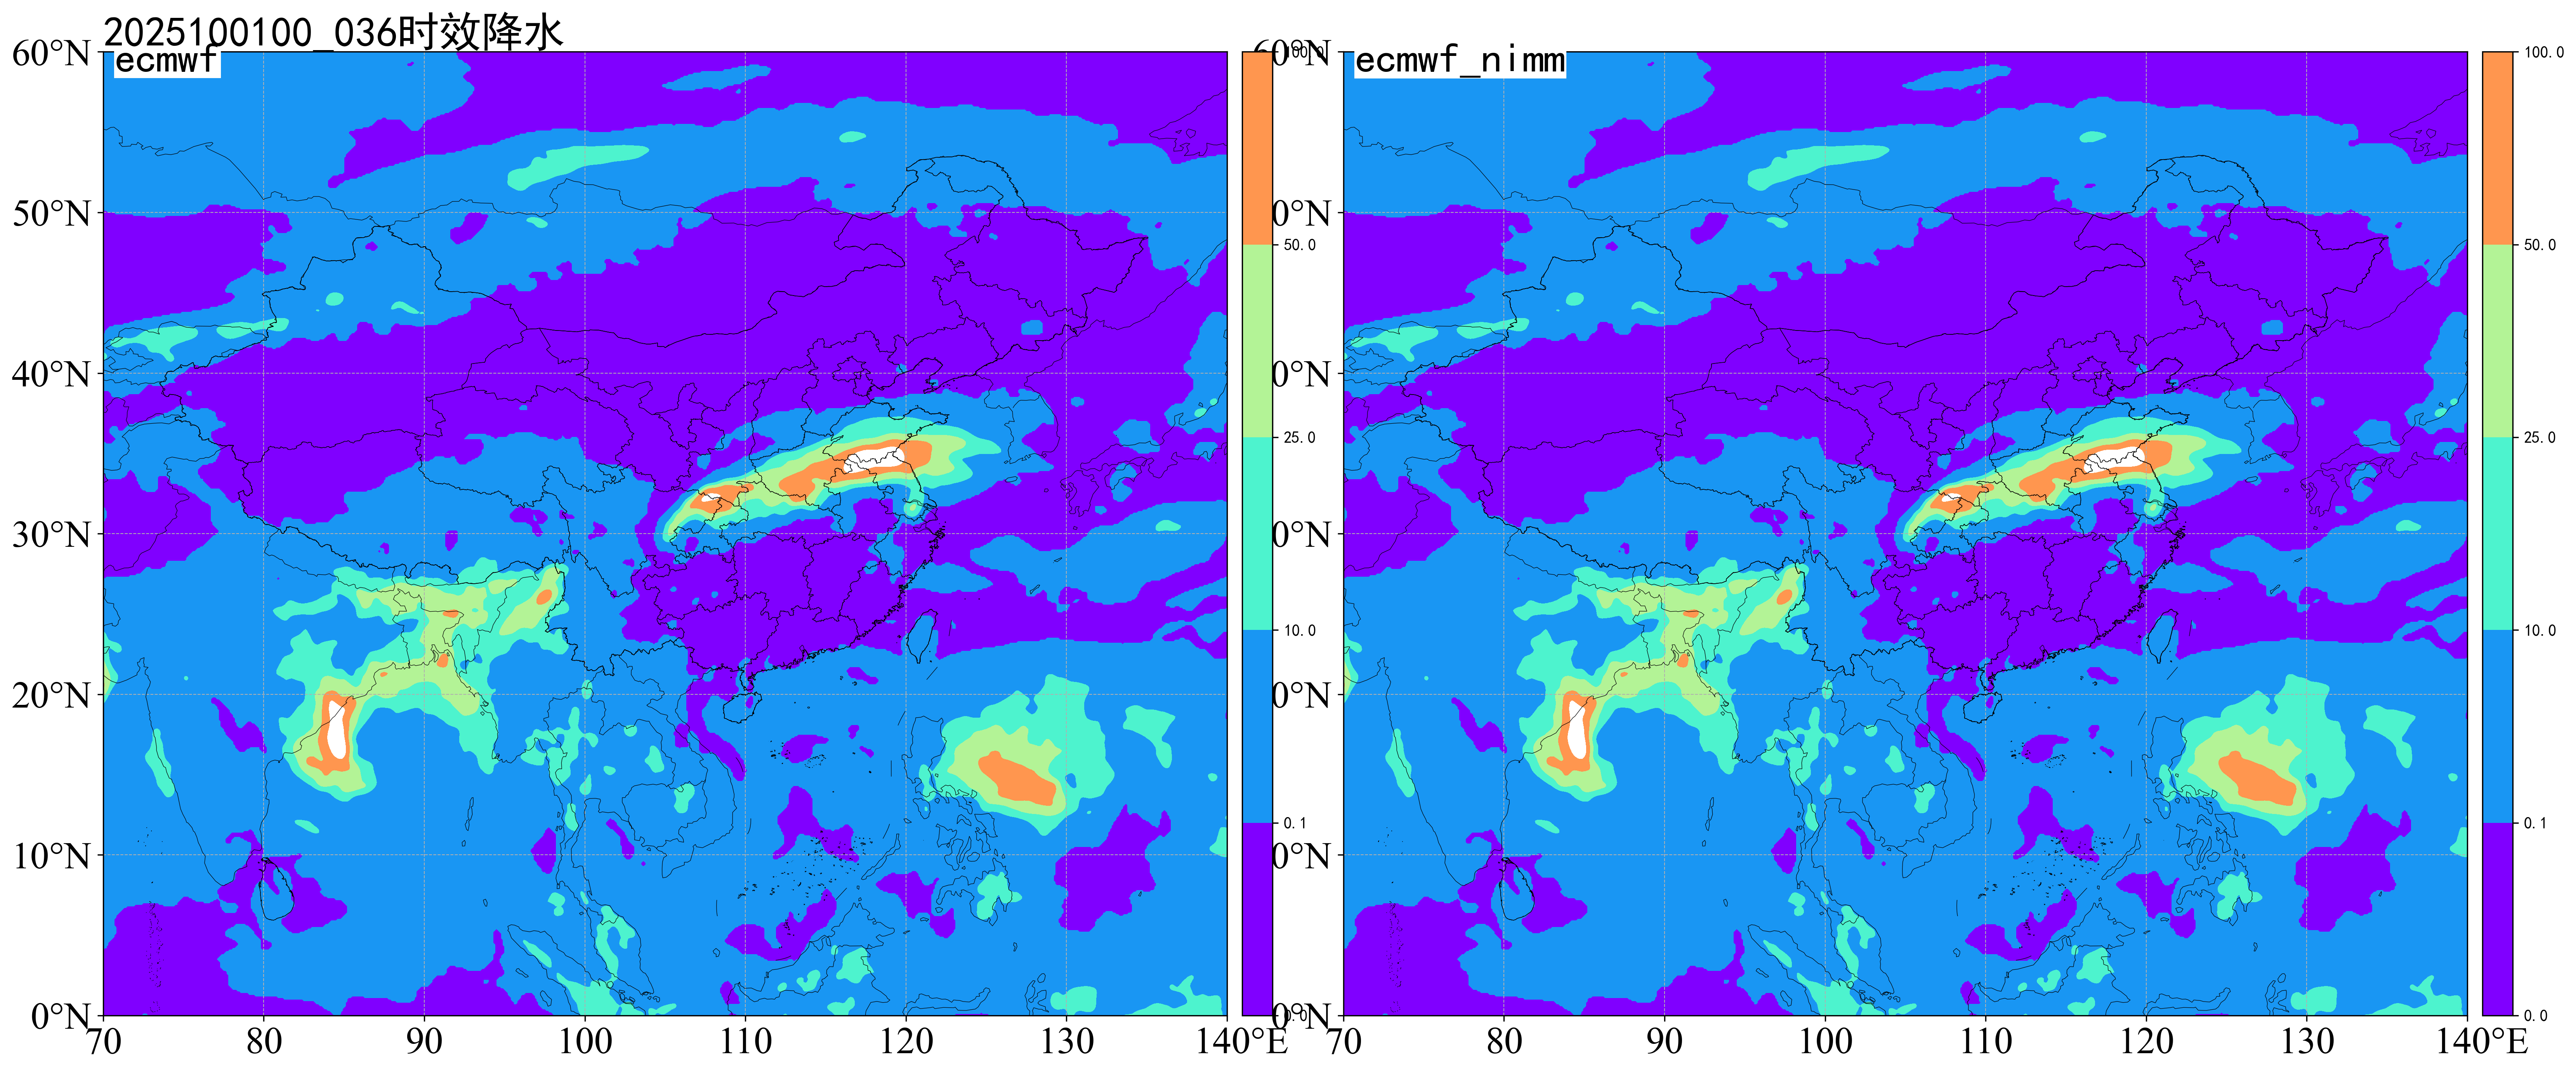

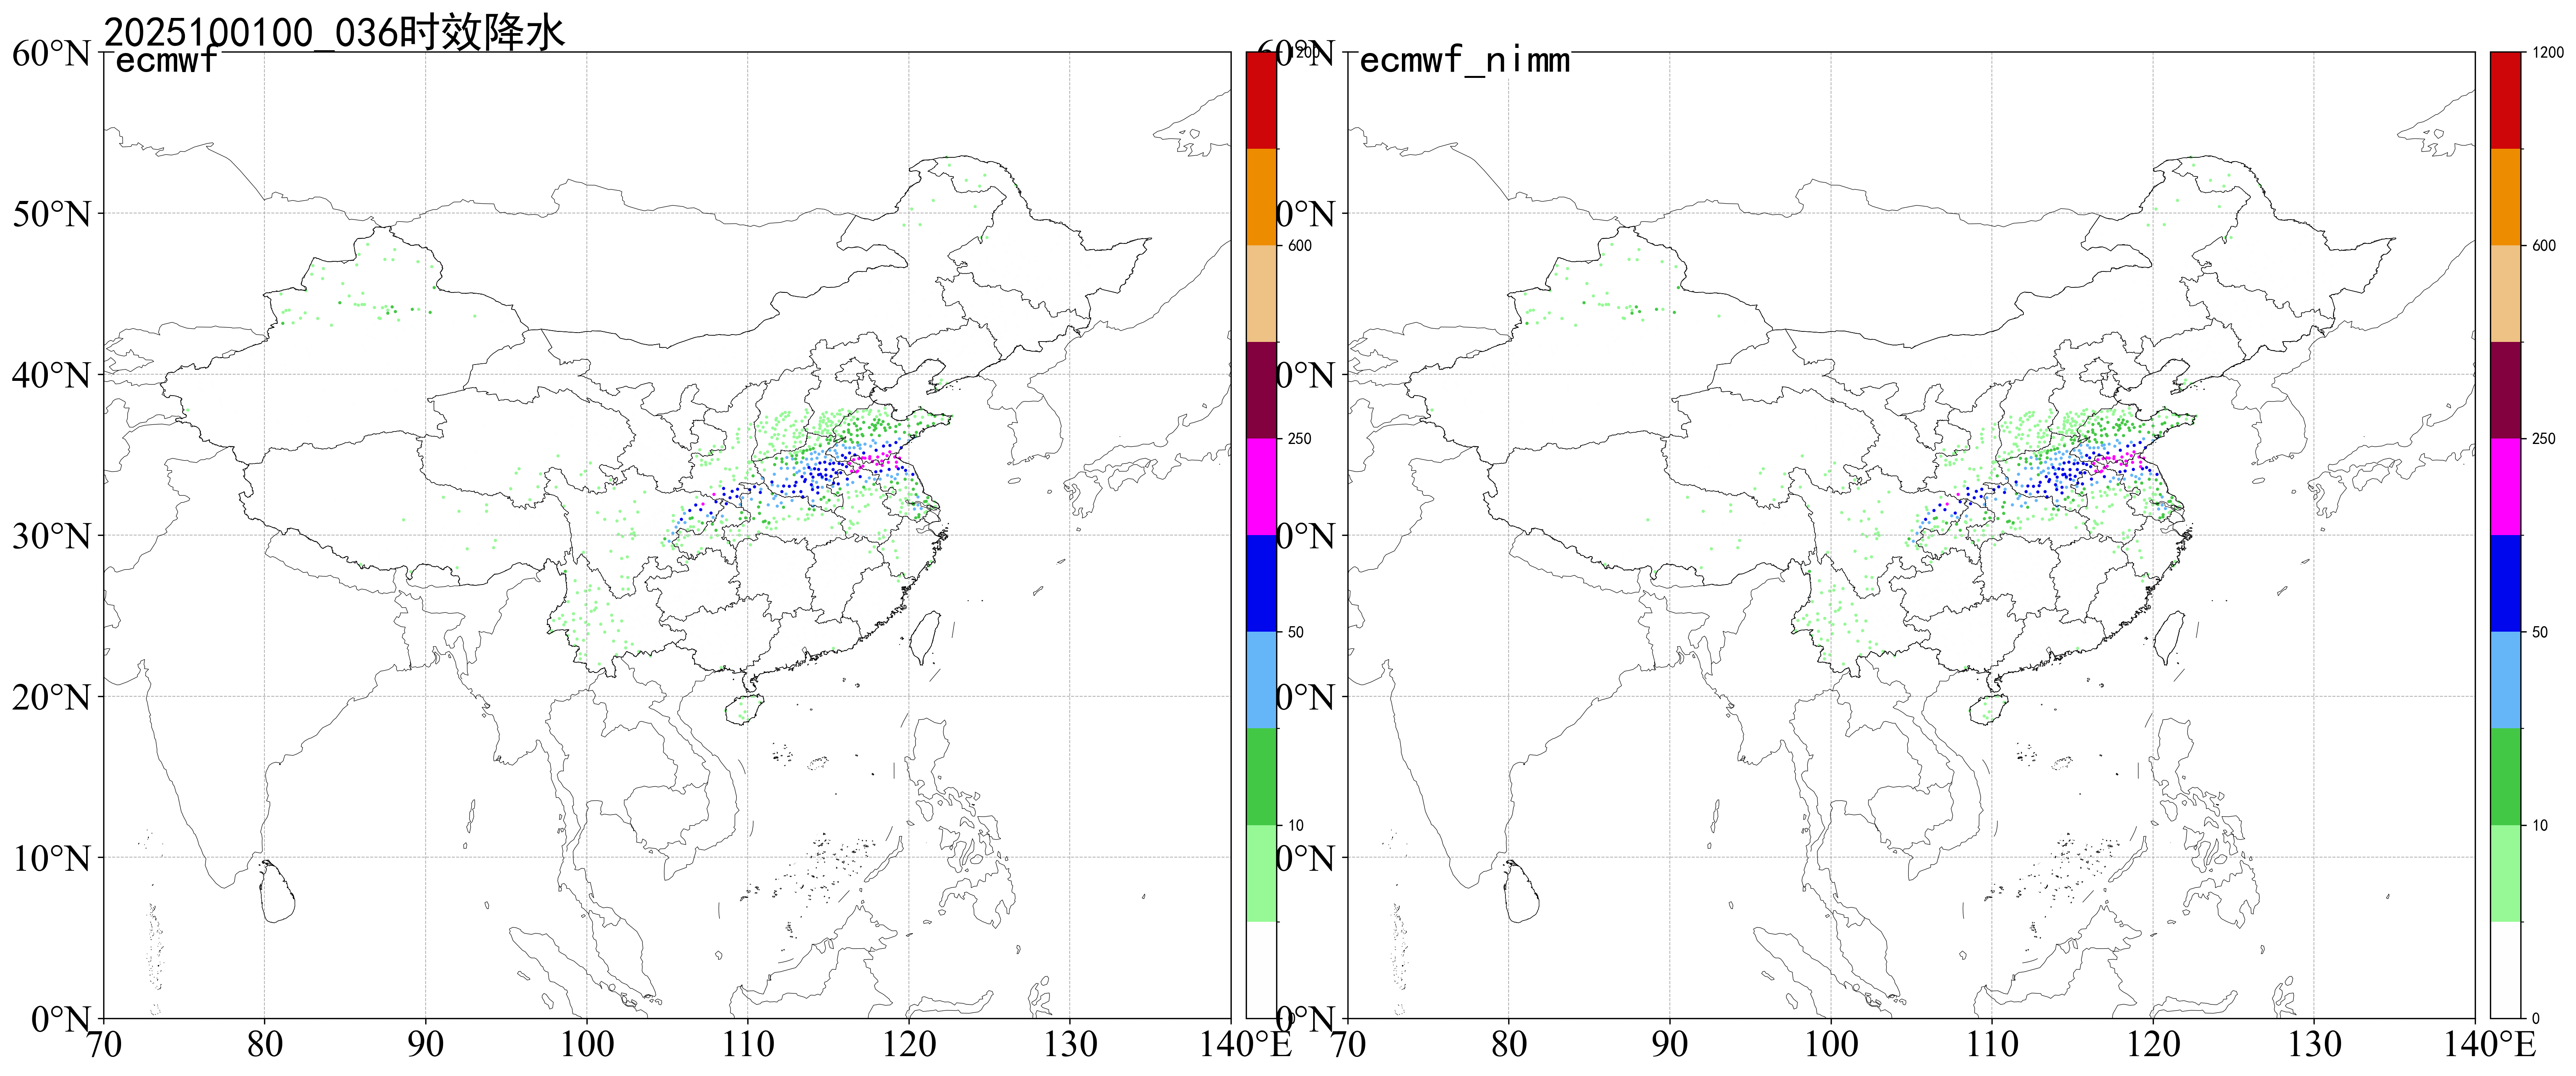

In [2]:
import meteva_base as meb
import numpy as np
import matplotlib.pyplot as plt
import datetime


ecmwf_v2 = r'D:/Work/optimize_TP_24H_250402/resource/output/rain24/ecmwf/YYYYMMDDHH/YYYYMMDDHH.TTT.m4'
ecmwf_nimm = r'D:/Work/optimize_tp_24h/resource/output/rain24/ecmwf/YYYYMMDDHH/YYYYMMDDHH.TTT.m4'
png_dir = r'D:/Work/optimize_tp_24h/resource/output/pngs/YYYYMMDD'
dtime = 36
ftime = '2025100100'

fo_time = datetime.datetime.strptime(ftime, '%Y%m%d%H')
ec_2_path = meb.get_path(ecmwf_v2, fo_time, dtime)
ec_1_path = meb.get_path(ecmwf_nimm, fo_time, dtime)
pg_path = meb.get_path(png_dir, fo_time)

ec1_grd = meb.read_griddata_from_micaps4(ec_2_path)
ec2_grd = meb.read_griddata_from_micaps4(ec_1_path)

map_extend = [70.0, 140.0, 0, 60.0]
axs = meb.creat_axs(2, map_extend, ncol=2, add_index=['ecmwf', 'ecmwf_nimm'],
                    sup_title=f'{ftime}_{dtime:03d}时效降水', sup_fontsize=26, wspace=1, height=26, width=26)
clevs = np.array([0, 0.1, 10, 25, 50, 100])
meb.add_contourf(axs[0], ec1_grd, cmap='rainbow', clevs=clevs, add_colorbar=True)
meb.add_contourf(axs[1], ec2_grd, cmap='rainbow', clevs=clevs, add_colorbar=True)

# plt.savefig(f"{pg_path}/{ftime}_{dtime:03d}_1.png", bbox_inches='tight')


ecmwf_v2 = r'D:/Work/optimize_TP_24H_250402/resource/output/rain24/ecmwf/YYYYMMDDHH/YYYYMMDDHH.TTT.m3'
ecmwf_nimm = r'D:/Work/optimize_tp_24h/resource/output/rain24/ecmwf/YYYYMMDDHH/YYYYMMDDHH.TTT.m3'
dtime = 36
ec_2_path = meb.get_path(ecmwf_v2, fo_time, dtime)
ec_1_path = meb.get_path(ecmwf_nimm, fo_time, dtime)

ec1_sta = meb.read_stadata_from_micaps3(ec_2_path)
ec2_sta = meb.read_stadata_from_micaps3(ec_1_path)

axs = meb.creat_axs(2, map_extend, ncol=2, add_index=['ecmwf', 'ecmwf_nimm'],
                    sup_title=f'{ftime}_{dtime:03d}时效降水', sup_fontsize=26, wspace=1, height=26, width=26)
meb.add_scatter(axs[0], ec1_sta, cmap=meb.cmaps.rain_24h, add_colorbar=True, alpha=1)
meb.add_scatter(axs[1], ec2_sta, cmap=meb.cmaps.rain_24h, add_colorbar=True, alpha=1)

# plt.savefig(f"{pg_path}/{ftime}_{dtime:03d}_2.png", bbox_inches='tight')

## 9. 结果检验对比

       level                time  dtime     id     lon    lat         ob  \
0          0 2025-10-01 08:00:00     36  50136  122.52  52.97   1.600000   
1          0 2025-10-01 08:00:00     36  50137  122.37  53.47   0.200000   
2          0 2025-10-01 08:00:00     36  50246  124.72  52.35   2.400000   
3          0 2025-10-01 08:00:00     36  50247  123.57  52.03   2.200000   
4          0 2025-10-01 08:00:00     36  50349  124.40  51.67   0.200000   
...      ...                 ...    ...    ...     ...    ...        ...   
48215      0 2025-10-01 20:00:00    252  59945  109.70  18.65  14.200000   
48216      0 2025-10-01 20:00:00    252  59948  109.58  18.22   6.800000   
48217      0 2025-10-01 20:00:00    252  59951  110.33  18.80  50.799999   
48218      0 2025-10-01 20:00:00    252  59954  110.03  18.55  15.300000   
48219      0 2025-10-01 20:00:00    252  59981  112.33  16.83   0.100000   

       optimize_TP_24H_250402  optimize_tp_24h  
0                        0.63         

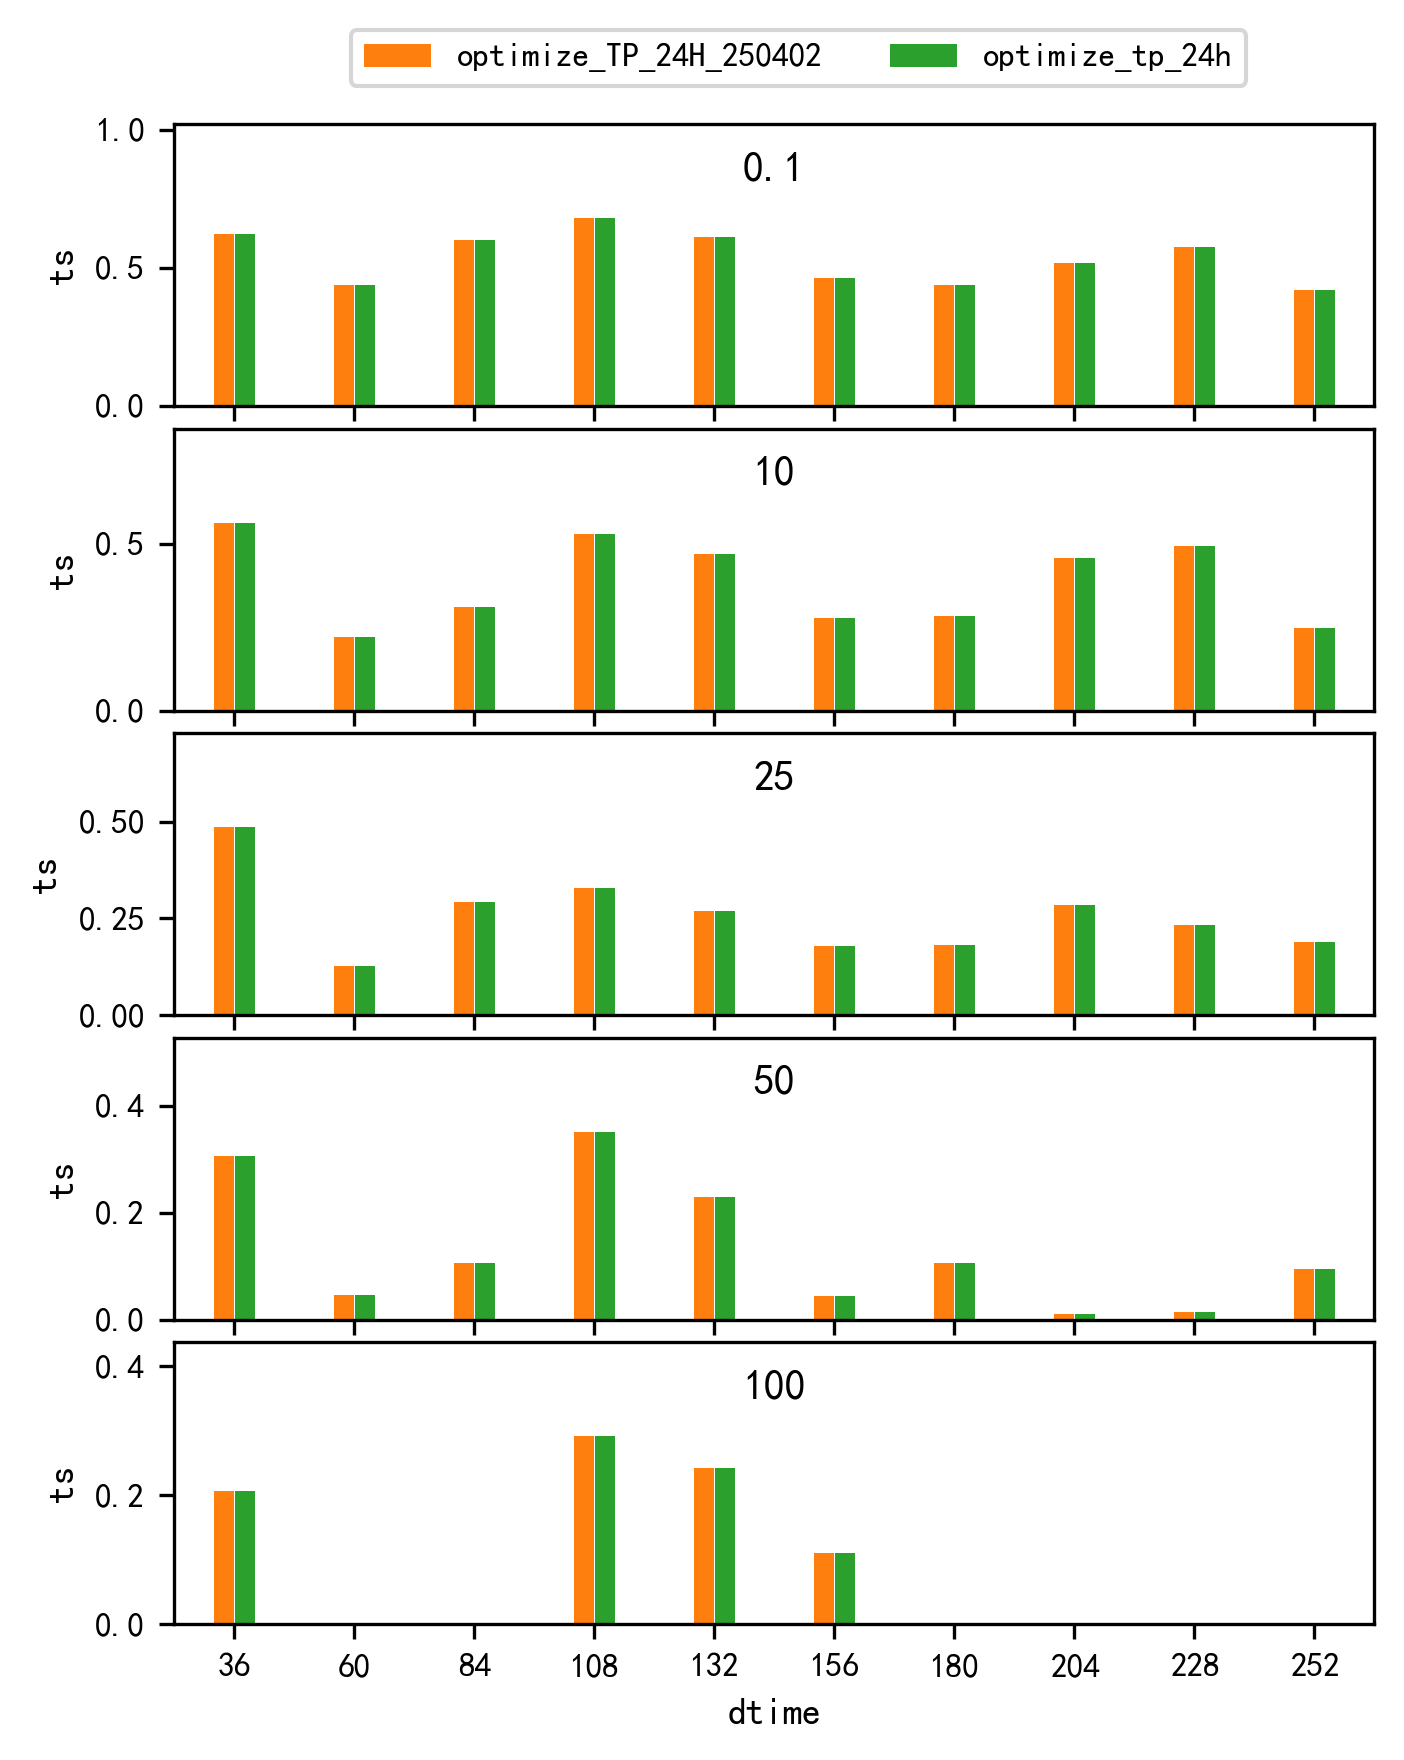

In [7]:
import meteva
import pandas as pd
import meteva_base as meb

import meteva.method as mem
import meteva.product as mpd


from datetime import datetime

h5_file = "D:/Work/optimize_tp_24h/resource/output/verify_data.h5"
sta_all = pd.read_hdf(h5_file, key="sta_all")
print(sta_all)
product_list = ["ec_dz", "optimize_tp_24h"]
grade_list = [0.1, 10, 25, 50, 100]
# get_ts(sta_all, grade_list, product_list, h5_file)  # 保存ts评分结果
result = mpd.score(sta_all, mem.ts, grade_list=grade_list, g="dtime", plot="bar", ncol=1, save_path=f"ts_bar.png", show=True)